## Modelling Estonian Energy Supply

Forecasting electricity prices in the Estonian grid is a challenging problem due to two compounding sources of complexity. First, supply-side uncertainty is high, as generation depends heavily on variable renewables such as wind, whose output is inherently difficult to predict. Second, Estonia operates within the interconnected Nordic-Baltic electricity market, meaning prices are strongly influenced by cross-border flows from neighboring bidding zones: Latvia, Lithuania, and Finland. Ignoring these spatial dependencies risks producing systematically biased forecasts.
These characteristics motivate a model that is both temporally aware and spatially structured. We represent the Nordic-Baltic grid as a graph, with bidding zones as nodes and physical cross-border transmission flows as edges, and apply a Spatio-Temporal Graph Neural Network (ST-GNN) ([Hadou et al., 2022](   https://doi.org/10.48550/arXiv.2110.02880)). ST-GNNs are well-suited to this setting, as they jointly learn spatial dependencies across graph nodes and temporal dynamics across time steps, offering greater flexibility than univariate time series models. However, this flexibility comes at a cost: ST-GNNs require substantially more data, are harder to interpret, and are sensitive to the quality of the graph structure provided. The model is trained on seven years of hourly data (2019–2025) from the [Elering API](https://dashboard.elering.ee/assets/swagger-ui/index.html), supplemented with weather data from [Open-Meteo API](https://archive-api.open-meteo.com/v1/archive) and actual wind generation from [ENTSO-E API](https://transparency.entsoe.eu).

### Data and features

The Elering API provided hourly production, renewable production, electricity prices, and cross-border import/export flows between Estonia and Finland, Latvia, Lithuania, and Russia (the latter disconnected from the Baltic grid in 2025). All data was originally recorded at 15-minute or hourly resolution and aligned to a common hourly frequency. The target variable is Estonian domestic energy production (MW).
Input features include current-timestep production, available energy (defined as production minus net exports to Finland and Latvia), renewable production, cross-border import/export flows to Finland and Latvia, electricity prices. All are measured at the current timestep and therefore fully observable at forecast time without leakage. Additionally, 24-hour lagged versions of production and available energy are included to capture daily periodicity. Weather variables (temperature and wind speed at 10 m) and cyclic calendar encodings (hour, day-of-week, month) complete the feature set. Actual metered wind generation from [ENTSO-E](https://transparency.entsoe.eu) is included as an explicit feature to give the model a direct view of the wind component within total production. Frequency deviation from 50 Hz is included as a [grid stability signal](https://www.neso.energy/energy-101/electricity-explained/how-do-we-balance-grid/what-frequency), reflecting real-time supply-demand imbalance across the synchronous grid .
No unnecessary lags are applied to current-state measurements such as production or flows, as these reflect the state of the system at forecast time and are fully observable. All of these input data are fetched from the corresponding APIs.
The 24-hour lag is retained only for features where yesterday's value at the same hour carries predictive signal beyond the current reading.


### Graph structure

The four bidding zones — Estonia (EE), Finland (FI), Latvia (LV), and Lithuania (LT) — form the nodes of the graph. Edges represent active cross-border interconnections, with Estonia connected to Finland and Latvia, and Latvia connected to Lithuania. All edges are undirected and weighted by the absolute mean historical import/export flow on each connection, normalised before training.
Estonia, as the target node, carries the full feature set described above. The neighboring nodes (FI, LV, LT) carry a reduced feature set consisting of their local electricity prices and the cross-border flows directed toward Estonia, reflecting the information that is physically transmitted across the interconnections. This asymmetry in node features is intentional: Estonia contains substantially more features than its neighbors, as the model is trained to predict Estonian domestic production.

<img src="../figures/Energy_grid.png" width="10%">
Figure 1: Graph structure of the Nordic-Baltic electricity market.



The topology reflects both the geographical layout of the region and the physical transmission infrastructure: edges correspond to active high-voltage interconnections between bidding zones. Estonia has no direct cable connection to Lithuania, so no edge is drawn between them. Russia, while historically connected to the Estonian grid, was excluded as a graph node due to limited data availability The electricity prices in Russia are not publicly transparent. However, the cross-border flow between Estonia and Russia is retained as a feature within the Estonian node itself.

### Sequence construction and splits

We use a sliding window of 48 hours (2 days) as the input sequence, with the model tasked to predict the 24-hour production profile of the following day. This sequence length yielded comparable performance to longer windows of 168 hours (1 week) at substantially lower computational cost.
Given that training a high-performing GNN was not the primary objective of this study, but rather a necessary step toward producing reliable energy simulations, a simple holdout strategy was adopted in place of full cross-validation. The last 20% of the data constitutes the validation set, and January 2026 is reserved entirely as the test set. Both partitions adhere to strict chronological ordering, with no shuffling across sets. A systematic cross-validation procedure would in principle allow for a more rigorous exploration of the trade-off between feature selection, hyperparameter tuning, and network architecture. However, given the computational and time constraints of this project, configurations were evaluated through structured manual experimentation, with the best-performing setup selected on the basis of validation performance.
All features and time series were differenced and normalised prior to training. Differencing was applied to address non-stationarity in the production signal, while normalisation constrains the input range across features, mitigating the risk of exploding gradients and promoting stable optimisation dynamics.
No unnecessary lags are applied to current-state measurements such as production or flows, as these quantities are fully observable at forecast time and introduce no leakage. The 24-hour lag is retained exclusively for features where the value at the equivalent hour on the preceding day carries predictive signal beyond the current observation.

### Model architecture
The paper by Hadou et al. (2022) introduces a Spatio-Temporal Graph Neural Network architecture designed to jointly process time-varying signals defined over a graph, by composing graph and time convolutional filters into a unified space-time shift operator. A key theoretical contribution is the proof that the architecture is stable under both graph perturbations (changes in network topology) and time perturbations (irregular sampling), meaning small changes in the underlying structure produce proportionally small changes in the output. The architecture is validated on decentralised control tasks such as multi-agent flocking and motion planning, where it outperforms conventional decentralised controllers.
Following the spatio-temporal forecasting framework of [Hadou et al. (2022)](https://doi.org/10.48550/arXiv.2110.02880), we implement a GATv2-based spatial module combined with a GRU temporal module.
The ST-GNN consists of two components: a spatial module and a temporal module. The spatial module applies two successive GATv2 graph attention layers to each hourly graph snapshot, with edge attributes encoding the normalised cross-border flow magnitudes. Each attention layer uses four attention heads with the outputs averaged, allowing the model to attend to different aspects of the neighbourhood structure simultaneously. Residual connections are added after each attention layer to stabilise training and prevent representational collapse in deeper networks.
The temporal module operates on the Estonia node exclusively. The Estonian node embedding is concatenated with an attention-weighted mean of the three neighbour embeddings (FI, LV, LT), where the attention weights are computed as a soft alignment between the Estonian embedding and each neighbour. Positional embeddings are added to the Estonian component to make the sequence order explicit, as GRUs are not inherently position-aware when processing irregular patterns. This combined sequence is passed through a two-layer GRU with dropout applied between the internal GRU layers. An additional dropout layer is applied to the final hidden state before decoding, as PyTorch's GRU dropout does not act on the output of the last layer.
The decoder consists of a two-layer feed-forward network with a LayerNorm applied after the first linear layer, followed by a ReLU activation and dropout. LayerNorm was preferred over BatchNorm for its robustness under distribution shift, which is a relevant concern in energy time series where the statistical properties of the signal can vary across seasons and years. The network outputs three quantile estimates: P10, P50, and P90, corresponding to a lower bound, median, and upper bound of the predicted production. Producing a forecast interval rather than a point estimate is particularly useful in an energy context, where understanding uncertainty is as important as the forecast itself. Quantile monotonicity (P10 ≤ P50 ≤ P90) is enforced via a differentiable sort operation, ensuring valid intervals without constraining the loss function.





/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


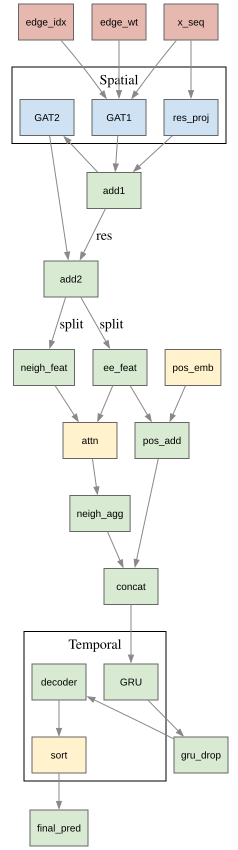

In [1]:
from STGNN import dot_code2
import graphviz, warnings
graph = graphviz.Source(dot_code2)
graph

### Training

The model was trained for up to 50 epochs using the Adam optimizer with an initial learning rate of $1e^{-5}$ and a weight decay of $1e^{-2}$ for regularization. To capture the uncertainty inherent in the data, the model was optimized using a Quantile Loss function targeting the 0.1, 0.5, and 0.9 quantiles. This approach allows for the estimation of the median while simultaneously establishing an 80% confidence interval to account for prediction variability. To ensure numerical stability and prevent the exploding gradient problem common in complex architectures, gradient norm clipping was implemented with a maximum threshold of 1.0. The optimization process was further refined through a ReduceLROnPlateau scheduler, which halved the learning rate if the validation loss failed to improve for eight consecutive epochs, allowing for finer weight adjustments as the model neared convergence. Finally, to minimize overfitting, an early stopping mechanism with a patience of 10 epochs was employed, which monitored validation performance and automatically restored the best-performing model weights before terminating of the training process.


### Evaluation

Following the training and validation phase, the model’s generalization capabilities were verified on a held-out test set covering the January 2026 period. While validation loss was used to guide hyperparameter tuning and early stopping, the test set provides an unbiased assessment of how the model performs on entirely unseen temporal patterns. After generating forecasts in evaluation mode, the predictions were inverse-transformed from their normalized state back to their original units in Megawatts (MW) to allow for a direct comparison with real-world observations.

The point-forecast accuracy was quantified using Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) relative to the 50th percentile (median) prediction. To evaluate the quality of the uncertainty estimation, we calculated the P10-P90 coverage, which measures the proportion of actual observations that fall within the predicted 80% confidence interval. This evaluation framework ensures that the model is not only accurate in its central tendency but also provides statistically reliable bounds for grid load and flow analysis. The results of this evaluation are as follows:

*   **Mean Absolute Error (MAE):** 121 MW
*   **Root Mean Square Error (RMSE):** \_\_\_\_\_\_\_ MW
*   **P10-P90 Coverage:** \_\_\_\_\_\_\_% (Target: $\ge 80\%$)

<img src="../figures/stgnn_resilience.png" width="100%">
Figure 1: Graph structure of the Nordic-Baltic electricity market.

### Scenarios

The trained model predicts Estonian domestic production for January 2026. Four scenarios are constructed as post-hoc adjustments to the model output, avoiding out-of-distribution extrapolation.

Since the model targets domestic production only, the full-grid scenario requires adding observed net cross-border flows back to the forecast. Isolation scenarios use the model output directly as the available energy, since no imports are possible. Wind scenarios add only the incremental generation from new capacity — computed as the difference between the scenario total and the baseline wind series — so that existing wind already captured in the model's training features is not double-counted.

- **S1 — Full grid (baseline):** net cross-border flows (imports and exports) are added to the model's production forecast, representing total available energy under the current interconnected grid.
- **S2 — Full isolation:** only domestic production is available, represented directly by the model output without any flow adjustment.
- **S3 — Isolation + Scenario A wind:** incremental generation from planned wind farm capacity is added to S2.
- **S4 — Isolation + Scenario B wind:** incremental generation from pipeline wind farm capacity is added to S2.

The P10–P90 uncertainty band from the model is shifted identically across all scenarios, reflecting that forecast uncertainty in domestic production applies regardless of the grid configuration.